<a href="https://colab.research.google.com/github/Nour-Tamimi/BinXtraining/blob/main/Week8/Day4/Day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_431d9e24cc1d2eaf9f6b19638c79a4fd"

In [25]:
!pip install -q kaggle --upgrade
!kaggle datasets download -d vencerlanz09/plastic-paper-garbage-bag-synthetic-images
!unzip -q plastic-paper-garbage-bag-synthetic-images.zip -d data

Dataset URL: https://www.kaggle.com/datasets/vencerlanz09/plastic-paper-garbage-bag-synthetic-images
License(s): CC-BY-SA-4.0
plastic-paper-garbage-bag-synthetic-images.zip: Skipping, found more recently modified local copy (use --force to force download)
replace data/Bag Classes/Bag Classes/Garbage Bag Images/00000000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace data/Bag Classes/Bag Classes/Garbage Bag Images/00000001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [27]:
base_folder = "data/Bag Classes/Bag Classes"

class_folders = {
    "Plastic Bag Images": "plastic",
    "Garbage Bag Images": "garbage",
    "Paper Bag Images": "paper",
}

IMAGES_PER_CLASS = 300   # keeping this small so training finishes quickly today

image_paths = []
labels = []

for folder_name, label in class_folders.items():
    folder_path = os.path.join(base_folder, folder_name)
    filenames = os.listdir(folder_path)[:IMAGES_PER_CLASS]

    for fname in filenames:
      image_paths.append(os.path.join(folder_path, fname))
      labels.append(label)

print("total images:", len(image_paths))

total images: 900


In [28]:
import cv2
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# Preprocess from Day 3.
def load_and_preprocess(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32)
    return img

In [29]:
# Now we use that function on EVERY image path we collected in Cell 2.
processed_images = []

for path in image_paths:
    processed_images.append(load_and_preprocess(path))

In [30]:
# Turn that list into one big NumPy array — this is the format models expect.
X = np.array(processed_images)

# Apply MobileNetV2's special scaling to ALL images at once (-1 to 1 range)
X = preprocess_input(X)

#   900   = number of images
#   224,224 = height, width
#   3     = color channels (R, G, B)
print("X shape:", X.shape)

X shape: (900, 224, 224, 3)


In [31]:
# Models can't understand text like "plastic" — they need numbers.
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Convert our list of text labels into a list of numbers
y_numbers = label_encoder.fit_transform(labels)

In [32]:
# Neural networks for classification usually want labels in "one-hot" format:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y_numbers)

print("y shape:", y.shape)   # 900 images, 3  classes

y shape: (900, 3)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("training images:", X_train.shape[0])
print("test images:", X_test.shape[0])

training images: 720
test images: 180


In [34]:
# This is the pre-trained model — it already knows how to recognize general
# shapes, textures, and patterns from being trained on millions of images.
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),   # matches the size we resized our images to
    include_top=False,           # cut off its original final layer
    weights="imagenet"           # load its pre-trained knowledge
)

# "Freeze" the base model — this means during training, we will NOT change
# anything it already learned. We're only going to train our new, small
# classification layer on top of it. This is the core idea of transfer learning.
base_model.trainable = False

# Now build our own small model: MobileNetV2's knowledge, plus our own
# classification head on top that learns to output "plastic"/"paper"/"garbage".
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,                                  # the frozen, pre-trained base
    layers.GlobalAveragePooling2D(),              # shrinks its output down to a simple list of numbers
    layers.Dense(64, activation="relu"),          # a small learning layer
    layers.Dropout(0.3),                          # randomly "turns off" some neurons during training, to reduce overfitting
    layers.Dense(3, activation="softmax")         # final output: 3 numbers (one probability per class) that add up to 1
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,163 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
from tensorflow.keras.callbacks import EarlyStopping
# "Compiling" means telling the model HOW to learn:
model.compile(
    optimizer="adam",                  # the algorithm that adjusts weights during training
    loss="categorical_crossentropy",   # how we measure "wrongness" for multi-class problems like ours
    metrics=["accuracy"]               # what to report while training, so we can watch progress
)

early_stop = EarlyStopping(
    monitor="val_loss",        # watch performance on the held-out test set
    patience=3,                 # allow 3 epochs with no improvement before stopping
    restore_best_weights=True   # roll back to the best epoch, not the last one
)



# This is where actual learning happens.
# epochs=5 means it will look at the entire training set 5 times over.
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,                  # upper limit — it likely won't reach this
    batch_size=32,
    callbacks=[early_stop]      # plug in the early stopping rule
)


Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.7236 - loss: 0.6600 - val_accuracy: 0.9111 - val_loss: 0.2070
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9264 - loss: 0.2078 - val_accuracy: 0.9556 - val_loss: 0.1328
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9722 - loss: 0.1038 - val_accuracy: 0.9556 - val_loss: 0.1046
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9708 - loss: 0.0882 - val_accuracy: 0.9611 - val_loss: 0.0969
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9875 - loss: 0.0603 - val_accuracy: 0.9778 - val_loss: 0.0745
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9875 - loss: 0.0433 - val_accuracy: 0.9833 - val_loss: 0.0682
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9944 - loss: 0.0311 - val_accuracy: 0.9667 - val_loss: 0.0902
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9917 - loss: 0.0321 - val_accuracy: 0.9778 - val_loss:

## Training Summary — Model Training with Early Stopping

**What happened:** Trained a MobileNetV2-based transfer learning model for
up to 30 epochs, using early stopping (`patience=3`, monitoring `val_loss`).

**Result:** Training automatically stopped after epoch 19, once `val_loss`
went 3 epochs in a row without improving. The model's final weights were
rolled back to **epoch 16** — its best point — not the epoch it happened to
stop on.

**Best epoch (16) performance:**
- Training accuracy: 100%
- Validation accuracy: 98.3%
- Validation loss: 0.0458

**Why this isn't overfitting:** Training accuracy hit 100% early on, but
validation accuracy stayed high and stable (96–98%) the whole time instead
of dropping. A real overfitting case would show validation accuracy
falling while training accuracy stays perfect — that didn't happen here.

**Why early stopping mattered:** Without it, training would have kept
running for the full 30 epochs and possibly saved a *worse* model than
epoch 16, purely because it stopped at a bad epoch by luck. Early stopping
+ `restore_best_weights=True` guarantees we keep the actual best version.

In [39]:
# This is the SAME preprocessing recipe we used to build X for training.
# It must match exactly, or we get training/serving skew (today's key warning).
def preprocess_for_model(path):
    img = cv2.imread(path)                        # read the image (BGR)
    img = cv2.resize(img, (224, 224))              # resize to match training
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)     # fix color order
    img = img.astype(np.float32)                   # convert to decimal numbers
    img = np.expand_dims(img, axis=0)               # add batch dimension: (1, 224, 224, 3)
    img = preprocess_input(img)                     # MobileNetV2's exact scaling (-1 to 1)
    return img

In [40]:
# These are the class names in the SAME order LabelEncoder used earlier.
# We printed this already: ['garbage' 'paper' 'plastic']
class_names = label_encoder.classes_
# This is the one function that takes a raw image path in, and gives a class name out.
def predict(image_path):
    processed = preprocess_for_model(image_path)      # step 1: preprocess
    probabilities = model.predict(processed, verbose=0)  # step 2: run through the model
    predicted_index = np.argmax(probabilities)          # step 3: pick highest probability
    predicted_class = class_names[predicted_index]
    confidence = probabilities[0][predicted_index]
    return predicted_class, confidence

In [41]:
# Grab one path we already know from earlier (adjust index if you want a different one)
test_path = image_paths[0]

predicted_class, confidence = predict(test_path)

print("image:", test_path)
print("predicted class:", predicted_class)
print("confidence:", confidence)

image: data/Bag Classes/Bag Classes/Plastic Bag Images/00001424.jpg
predicted class: plastic
confidence: 0.99646324


In [42]:
# Ask the model to predict on all 180 test images at once (already preprocessed,

predictions_raw = model.predict(X_test)

# argmax picks the class with the highest probability, for each row.
predicted_indices = np.argmax(predictions_raw, axis=1)

# y_test is one-hot encoded (e.g. [0,0,1]) — convert it back to plain indices too
true_indices = np.argmax(y_test, axis=1)

# Convert both from numbers back into class names, for readability
predicted_labels = class_names[predicted_indices]
true_labels = class_names[true_indices]

print("first 10 true labels:     ", true_labels[:10])
print("first 10 predicted labels:", predicted_labels[:10])

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step
first 10 true labels:      ['plastic' 'paper' 'paper' 'garbage' 'plastic' 'plastic' 'paper' 'garbage'
 'plastic' 'paper']
first 10 predicted labels: ['plastic' 'paper' 'paper' 'garbage' 'plastic' 'plastic' 'paper' 'garbage'
 'plastic' 'paper']


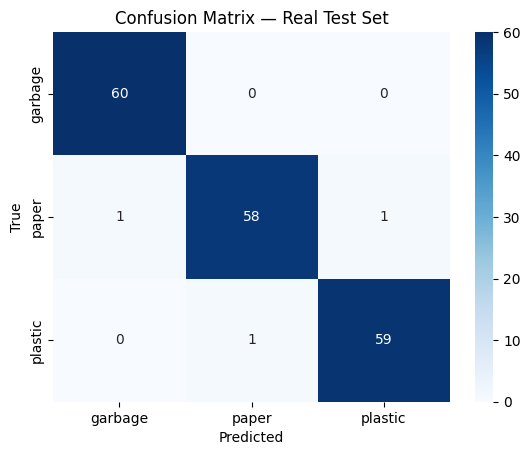

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Build the confusion matrix: rows = true class, columns = predicted class
cm = confusion_matrix(true_labels, predicted_labels, labels=class_names)

# Draw it as a heatmap so it's easy to read
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Real Test Set")
plt.show()

In [44]:
# Go through all 180 test predictions and find the ones where true != predicted
misclassified_indices = []

for i in range(len(true_labels)):
    if true_labels[i] != predicted_labels[i]:
        misclassified_indices.append(i)

print("number of misclassified examples:", len(misclassified_indices))
print("their positions in the test set:", misclassified_indices)

number of misclassified examples: 3
their positions in the test set: [23, 38, 91]


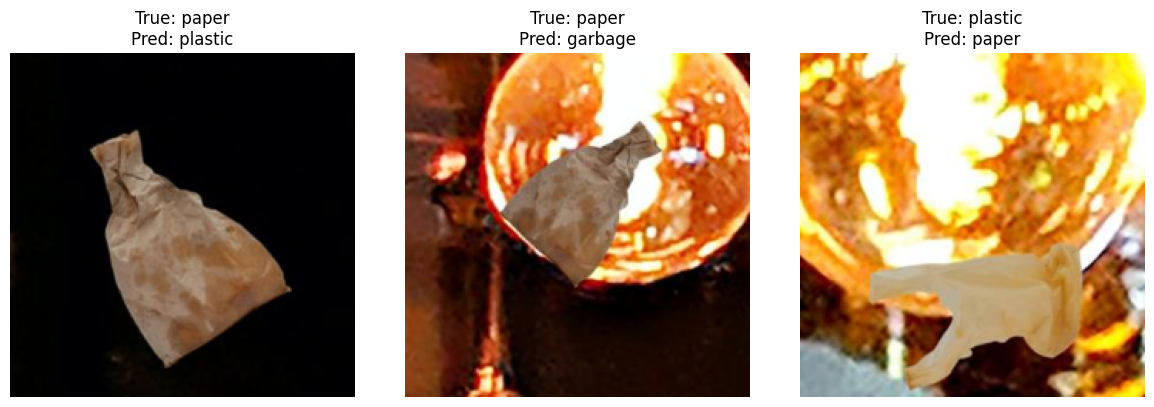

In [45]:
# X_test images were preprocessed with MobileNetV2's scaling (-1 to 1),
# which matplotlib can't display directly, so we rescale back to 0-1 just for viewing.
fig, axes = plt.subplots(1, len(misclassified_indices), figsize=(12, 4))

for ax, idx in zip(axes, misclassified_indices):
    img_to_show = (X_test[idx] + 1) / 2   # undo the -1 to 1 scaling, back to roughly 0-1
    ax.imshow(img_to_show)
    ax.set_title(f"True: {true_labels[idx]}\nPred: {predicted_labels[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Misclassified Examples — Error Analysis

1. **True: paper, Predicted: plastic**
   The bag has a smooth, glossy sheen and a rounded sack shape rather than
   paper's typical crisp folds → **model weakness**: paper bags with a
   glossy/rounded appearance are visually ambiguous with plastic, and the
   model may be leaning too heavily on surface shine as a cue.

2. **True: paper, Predicted: garbage**
   The paper bag itself is clear, but it's shot against a bright orange
   fire-like background, very different from typical training backgrounds
   → **data issue**: unusual/distracting background likely interfered
   with the model's focus on the bag itself.

3. **True: plastic, Predicted: paper**
   Same fiery background as #2, and the bag's beige/tan matte color closely
   resembles paper's typical color → **model weakness** (with a data
   contribution): plastic bags in non-standard colors/lighting aren't
   reliably distinguished from paper by texture/shape alone yet.

**Pattern spotted:** Two of the three errors (#2, #3) share the same unusual
fiery-orange background — suggests the model may be somewhat sensitive to
background noise, not just the bag itself. A next step worth trying: check
how many training images have plain vs. busy backgrounds, and whether more
augmentation (or more examples with noisy backgrounds) would help.